# Proyek Klasifikasi Gambar: Image Submission Classification
- **Nama:** Rois Hoiron
- **Email:** rois.khoiron@gmail.com
- **ID Dicoding:** khoironrois

## Import Semua Packages/Library yang Digunakan

In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks
from pathlib import Path
import os
import kagglehub
AUTOTUNE = tf.data.AUTOTUNE

## Data Preparation

### Data Loading

In [6]:
# Download dataset from Kaggle
data_path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

# Load metadata and organize images by category
metadata_path = Path(data_path) / 'myntradataset' / 'styles.csv'
df = pd.read_csv(metadata_path, on_bad_lines="skip", engine="python")

# Use masterCategory as label (7 classes)
df['label'] = df['masterCategory'].astype('category')
df['label_id'] = df['label'].cat.codes
label_names = df["label"].cat.categories.tolist()
print(f'Classes: {label_names}')

# Create class directories and copy images (optimized - batch copy)
import shutil
from pathlib import Path
images_dir = Path(data_path) / "images"
class_base = Path(data_path) / "images_by_category"
if class_base.exists():
    shutil.rmtree(class_base)
class_base.mkdir()

# Vectorized copy - filter valid images first
df_valid = df[df['id'].astype(str).apply(lambda x: (images_dir / f"{x}.jpg").exists())].copy()
print(f'Valid images: {len(df_valid)} / {len(df)}')

# Group by label and copy in batches
for label_id, group in df_valid.groupby('label_id'):
    cat_dir = class_base / str(int(label_id))
    cat_dir.mkdir(exist_ok=True)
    for _, row in group.iterrows():
        img_file = images_dir / f"{row['id']}.jpg"
        if img_file.exists():
            shutil.copy2(img_file, cat_dir / img_file.name)

data_dir = class_base
batch_size = 16
img_height, img_width = 128, 128

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(f'Found classes: {class_names}')


Classes: ['Accessories', 'Apparel', 'Footwear', 'Free Items', 'Home', 'Personal Care', 'Sporting Goods']
Valid images: 44419 / 44424
Found 44419 files belonging to 7 classes.
Using 35536 files for training.
Found 44419 files belonging to 7 classes.
Using 8883 files for validation.
Found classes: ['0', '1', '2', '3', '4', '5', '6']


### Data Preprocessing

#### Split Dataset

In [7]:

def preprocess(image, label):
    return tf.cast(image, tf.float32) / 255.0, tf.cast(label, tf.int64)

train_ds = train_ds.map(preprocess).shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess).prefetch(AUTOTUNE)

# Split validation into val + test
test_ds = val_ds.take(200)
val_ds = val_ds.skip(200)


## Modelling

In [8]:
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])
model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax'),
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Evaluasi dan Visualisasi

Epoch 1/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7150 - loss: 0.7551

2221/2221 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - accuracy: 0.7884 - loss: 0.5822 - val_accuracy: 0.8897 - val_loss: 0.3451
Epoch 2/50
2219/2221 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8654 - loss: 0.3966

2221/2221 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - accuracy: 0.8756 - loss: 0.3727 - val_accuracy: 0.9169 - val_loss: 0.2822
Epoch 3/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8951 - loss: 0.3179

2221/2221 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9021 - loss: 0.3054 - val_accuracy: 0.9263 - val_loss: 0.2297
Epoch 4/50
2218/2221 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9093 - loss: 0.2825

2221/2221 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - accuracy: 0.9130 - loss: 0.2738 - val_accuracy: 0.9414 - val_loss: 0.1963
Epoch 5/50
2220/2221 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9196 - loss: 0.2525

2221/2221 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9225 - loss: 0.2487 - val_accuracy: 0.9433 - val_loss: 0.1958
Epoch 6/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9237 - loss: 0.2423 - val_accuracy: 0.9396 - val_loss: 0.2321
Epoch 7/50
2218/2221 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9297 - loss: 0.2282

2221/2221 ━━━━━━━━━━━━━━━━━━━━ 80s 17ms/step - accuracy: 0.9303 - loss: 0.2284 - val_accuracy: 0.9488 - val_loss: 0.1878
Epoch 8/50
2220/2221 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9362 - loss: 0.2140

2221/2221 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.9345 - loss: 0.2166 - val_accuracy: 0.9521 - val_loss: 0.1628
Epoch 9/50
2219/2221 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9374 - loss: 0.2102

2221/2221 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9358 - loss: 0.2125 - val_accuracy: 0.9578 - val_loss: 0.1507
Epoch 10/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9386 - loss: 0.2049 - val_accuracy: 0.9539 - val_loss: 0.1546
Epoch 11/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9404 - loss: 0.1962 - val_accuracy: 0.9565 - val_loss: 0.1530
Epoch 12/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 84s 18ms/step - accuracy: 0.9416 - loss: 0.1919 - val_accuracy: 0.9560 - val_loss: 0.1560
Epoch 13/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9443 - loss: 0.1891

2221/2221 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.9432 - loss: 0.1915 - val_accuracy: 0.9578 - val_loss: 0.1477
Epoch 14/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 46s 18ms/step - accuracy: 0.9443 - loss: 0.1855 - val_accuracy: 0.9511 - val_loss: 0.1785
Epoch 15/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9450 - loss: 0.1859 - val_accuracy: 0.9599 - val_loss: 0.1621
Epoch 16/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 46s 18ms/step - accuracy: 0.9446 - loss: 0.1830 - val_accuracy: 0.9571 - val_loss: 0.1558
Epoch 17/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 79s 18ms/step - accuracy: 0.9478 - loss: 0.1774 - val_accuracy: 0.9550 - val_loss: 0.1804
Epoch 18/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - accuracy: 0.9480 - loss: 0.1747 - val_accuracy: 0.9623 - val_loss: 0.1642


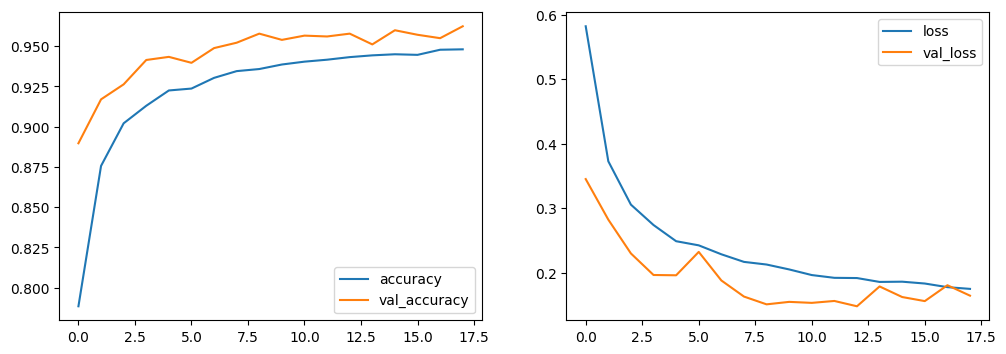

In [9]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = callbacks.ModelCheckpoint('best_model.h5', save_best_only=True)
history = model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stop, checkpoint])
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

## Konversi Model

In [12]:
model.export('saved_model/')
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model/')
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Aktifkan ops yang hanya ada di TensorFlow (Select ops)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,          # ops standar TFLite
    tf.lite.OpsSet.SELECT_TF_OPS            # ops tambahan (RandomFlip, RandomRotation, dsb.)
]

# (Opsional) beri representative dataset untuk kuantisasi
# def representative_data_gen():
#     for batch, _ in train_ds.take(100):
#         yield [batch]
# converter.representative_dataset = representative_data_gen

tflite_model = converter.convert()
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)
tfjs_converter_cmd = 'tensorflowjs_converter --input_format=tf_saved_model saved_model/ tfjs_model/'

Saved artifact at 'saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  140637096961680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687623504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687623120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687627920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687630224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687625616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687631568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687632336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687632720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687632528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140635687630416: T

## Inference (Optional)

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test Accuracy: {test_acc:.2%}')

200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9638 - loss: 0.1277
Test Accuracy: 96.38%
